In [88]:
import xarray as xr, regionmask, matplotlib, matplotlib.pyplot as plt, geopandas as gpd, cartopy, pandas as pd, re, numpy as np, glob, datetime
from dateutil.relativedelta import relativedelta
from functools import reduce

xr.set_options(keep_attrs = True)
matplotlib.rcParams['savefig.bbox'] = "tight"

from IPython.display import clear_output

x0 = 39.8; y0 = 21.4; k = 1

In [3]:
class MidpointNormalise(matplotlib.colors.Normalize):
    """ From: https://matplotlib.org/users/colormapnorms.html"""
    def __init__(self, vmin=None, vmax=None, midpoint=0, clip=False):
        self.midpoint = midpoint
        matplotlib.colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # I'm ignoring masked values and all kinds of edge cases to make a
        # simple example...

        result, is_scalar = self.process_value(value)
        self.autoscale_None(result)

        vlargest = max( abs( self.vmax - self.midpoint ), abs( self.vmin - self.midpoint ) )
        x, y = [ self.midpoint - vlargest, self.midpoint, self.midpoint + vlargest], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

In [4]:
def decode_times(ts):
    
    # Method to manually decode times
    
    inc = re.sub(" .+", "", ts.time.units)
    startdate = pd.Timestamp(re.sub(".+since ", "", ts.time.units)+' 00:00:00.000000').to_pydatetime()
    
    if inc == "years":
        new_times = [np.datetime64(startdate + relativedelta(years = i)) for i in ts.time.values]
    elif inc == "months":
        new_times = [np.datetime64(startdate + relativedelta(months = i)) for i in ts.time.values]
    elif inc == "days":
        new_times = [np.datetime64(startdate + relativedelta(days = i)) for i in ts.time.values]
    elif inc == "hours":
        new_times = [np.datetime64(startdate + relativedelta(hours = i)) for i in ts.time.values]
    else:
        print("TBD: " +inc)
        return
        
    ts = ts.assign_coords(time = new_times)
    
    return ts

# Download data 

## GMST

In [ ]:
# ! wget https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat -O data/gmst.txt

## Other Climexp data

In [ ]:
! wget https://climexp.knmi.nl/dyn_links/era5_tmax_daily_34-56E_16-33N_-999-lastyear.nc -O data/tmax_era5_reanalysis.nc

In [1]:
! wget https://climexp.knmi.nl/dyn_links/era5_tmin_daily_extended_34-56E_18-33N_-999-lastyear_su.nc -O data/tmin_era5_compiled.nc

--2026-05-27 19:51:07--  https://climexp.knmi.nl/dyn_links/era5_tmin_daily_extended_34-56E_18-33N_-999-lastyear_su.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 115565033 (110M) [application/x-netcdf]
Saving to: ‘data/tmin_era5_compiled.nc’

data/tmin_era5_comp 100%[===================>] 110.21M  57.9MB/s    in 1.9s    

2026-05-27 19:51:09 (57.9 MB/s) - ‘data/tmin_era5_compiled.nc’ saved [115565033/115565033]



In [136]:
! wget https://climexp.knmi.nl/dyn_links/era5_t2m_daily_34-56E_16-33N_-999-lastyear_su.nc -O data/t2m_era5_reanalysis.nc

--2026-05-27 13:43:54--  https://climexp.knmi.nl/dyn_links/era5_t2m_daily_34-56E_16-33N_-999-lastyear_su.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
connected. to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... 
HTTP request sent, awaiting response... 200 OK
Length: 135918540 (130M) [application/x-netcdf]
Saving to: ‘data/t2m_era5_reanalysis.nc’

data/t2m_era5_reana 100%[===================>] 129.62M  72.5MB/s    in 1.8s    

2026-05-27 13:43:56 (72.5 MB/s) - ‘data/t2m_era5_reanalysis.nc’ saved [135918540/135918540]



In [ ]:
! wget https://climexp.knmi.nl/dyn_links/tmax_cpc_daily_34-56E_16-33N_firstyear-lastyear.nc -O data/tmax_cpc.nc

In [22]:
! wget https://climexp.knmi.nl/dyn_links/tmin_cpc_daily_34-56E_18-33N_-999-lastyear_su.nc -O data/tmin_cpc.nc

--2026-05-27 19:58:09--  https://climexp.knmi.nl/dyn_links/tmin_cpc_daily_34-56E_18-33N_-999-lastyear_su.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
connected. to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... 
HTTP request sent, awaiting response... 200 OK
Length: 74347848 (71M) [application/x-netcdf]
Saving to: ‘data/tmin_cpc.nc’

data/tmin_cpc.nc    100%[===================>]  70.90M  63.6MB/s    in 1.1s    

2026-05-27 19:58:10 (63.6 MB/s) - ‘data/tmin_cpc.nc’ saved [74347848/74347848]



## Compile with latest forecast & analysis

### ERA5 tmax

In [153]:
ra = xr.open_dataset("data/tmax_era5_reanalysis.nc").tmax
xn, xx, yn, yx = [ra.lon[0].values - 0.25, ra.lon[-1].values + 0.25, ra.lat[-1].values - 0.25, ra.lat[0].values + 0.25]

# load analysis & forecast data
an = xr.open_dataset("data/oper_tmax_2026-05-26_daily.nc").mx2t6.rename("tmax", longitude = "lon", latitude = "lat")
fc = xr.open_dataset("data/forecast_tmax_2026-05-26_daily.nc").mx2t6.rename("tmax", longitude = "lon", latitude = "lat")

# regrid to same resolution as reanalysis for consistency
an = an.sel(lon = slice(xn,xx), lat = slice(yx,yn)).coarsen(lon = 2, lat = 2).mean()
fc = fc.sel(lon = slice(xn,xx), lat = slice(yx,yn)).coarsen(lon = 2, lat = 2).mean()

# compile & save
da = xr.concat([da - 273.15 if da.min() > 100 else da for da in [ra, an, fc]], "time")
da.to_netcdf("data/tmax_era5_compiled.nc")

### ERA5 t2m

In [18]:
ra = xr.open_dataset("data/t2m_era5_reanalysis.nc").t2m
xn, xx, yn, yx = [ra.lon[0].values - 0.25, ra.lon[-1].values + 0.25, ra.lat[-1].values - 0.25, ra.lat[0].values + 0.25]

# load analysis & forecast data
an = xr.open_dataset("data/oper_t2m_2026-05-26_daily.nc").t2m.rename(longitude = "lon", latitude = "lat")
fc = xr.open_dataset("data/forecast_t2m_2026-05-26_daily.nc").t2m.rename(longitude = "lon", latitude = "lat")

# subset & regrid to same resolution as reanalysis for consistency
an = an.sel(lon = slice(xn,xx), lat = slice(yx,yn)).coarsen(lon = 2, lat = 2).mean()
fc = fc.sel(lon = slice(xn,xx), lat = slice(yx,yn)).coarsen(lon = 2, lat = 2).mean()

# compile & save
da = xr.concat([da - 273.15 if da.min() > 100 else da for da in [ra, an, fc]], "time")
da.to_netcdf("data/t2m_era5_compiled.nc")

## Daily time series

In [33]:
for varnm in ["tmin", "tmax", "t2m"]:
    for ds_nm in ["cpc", "era5"]:
        fnm = sorted(glob.glob("data/"+varnm+"_"+ds_nm+"*"))
        
        if len(fnm) == 0: continue
        
        da = xr.open_dataset(fnm[0])[varnm]
        if da.min() > 100: da = da - 273.15

        rm = regionmask.defined_regions.natural_earth_v5_1_2.land_50.mask(da)
        da = da.where(rm == 0)
        ts = da.sel(lon = slice(x0-k, x0+k), lat = slice(y0+k, y0-k)).mean(["lat","lon"])
        ts.to_netcdf("data/"+varnm+"-daily_box_"+ds_nm+".nc")

# Annual time series

## tx1x, tn1x

In [36]:
for varnm in ["tmax", "tmin"]:
    for fnm in glob.glob("data/"+varnm+"-daily_box_*.nc"):
        print(fnm)
        ds_nm = fnm.split("_")[-1][:-3]
    
        ts = xr.open_dataset(fnm)[varnm]
        tx1x = ts.resample(time = "MS").max().groupby("time.month")[5]
        df = tx1x.assign_coords(time = tx1x.time.dt.year).rename(time = "year").to_dataframe()
        df.to_csv("ts/t"+varnm[-1]+"1x-may_box_"+ds_nm+".csv")

data/tmax-daily_box_cpc.nc
data/tmax-daily_box_era5.nc
data/tmin-daily_box_era5.nc
data/tmin-daily_box_cpc.nc


In [37]:
cpc = pd.read_csv("ts/tx1x-may_box_cpc.csv", index_col = "year")
era5 = pd.read_csv("ts/tx1x-may_box_era5.csv", index_col = "year")

## May mean

In [39]:
for fnm in glob.glob("data/t2m-daily_box_*.nc"):
    print(fnm)
    ds_nm = fnm.split("_")[-1][:-3]

    ts = xr.open_dataset(fnm).t2m
    tx1x = ts.resample(time = "MS").mean().groupby("time.month")[5]
    df = tx1x.assign_coords(time = tx1x.time.dt.year).rename(time = "year").to_dataframe()
    df.to_csv("ts/tmean-may_box_"+ds_nm+".csv")

data/t2m-daily_box_era5.nc


In [52]:
for fnm in glob.glob("data/tmin-daily_box_*.nc"):
    print(fnm)
    ds_nm = fnm.split("_")[-1][:-3]

    ts = xr.open_dataset(fnm).tmin
    tx1x = ts.resample(time = "MS").mean().groupby("time.month")[5]
    df = tx1x.assign_coords(time = tx1x.time.dt.year).rename(time = "year").to_dataframe()
    df.to_csv("ts/tn1g-may_box_"+ds_nm+".csv")

data/tmin-daily_box_era5.nc
data/tmin-daily_box_cpc.nc


<Axes: xlabel='year'>

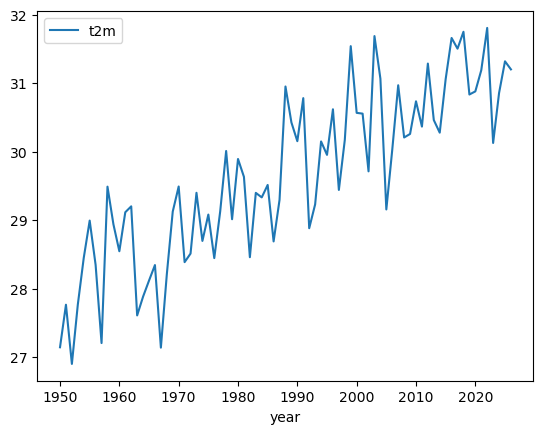

In [40]:
df.plot()

# Past reference values

### Tx1x

In [49]:
tx = xr.open_dataset("data/tmax-daily_box_era5.nc").tmax
tx_hist = tx.resample(time = "QS-DEC").max().groupby("time.season")["JJA"].sel(time = slice("1970","1990"))

str(tx_hist.mean().round(1).values) + " ("+ str(tx_hist.min().round(1).values) + ", " + str(tx_hist.max().round(1).values)+")"

'39.9 (38.1, 41.2)'

In [42]:
tx = xr.open_dataset("data/tmax-daily_box_cpc.nc").tmax
tx_hist = tx.resample(time = "QS-DEC").max().groupby("time.season")["JJA"].sel(time = slice("1970","1990"))

str(tx_hist.mean().round(1).values) + " ("+ str(tx_hist.min().round(1).values) + ", " + str(tx_hist.max().round(1).values)+")"

'41.9 (40.5, 43.9)'

### Tn1x

In [47]:
tx = xr.open_dataset("data/tmin-daily_box_era5.nc").tmin
tx_hist = tx.resample(time = "QS-DEC").max().groupby("time.season")["JJA"].sel(time = slice("1970","1990"))

str(tx_hist.mean().round(1).values) + " ("+ str(tx_hist.min().round(1).values) + ", " + str(tx_hist.max().round(1).values)+")"

'26.9 (25.9, 27.9)'

In [51]:
tx = xr.open_dataset("data/tmin-daily_box_cpc.nc").tmin
tx_hist = tx.resample(time = "QS-DEC").max().groupby("time.season")["JJA"].sel(time = slice("1970","1990"))

str(tx_hist.mean().round(1).values) + " ("+ str(tx_hist.min().round(1).values) + ", " + str(tx_hist.max().round(1).values)+")"

'28.7 (27.2, 30.0)'

### Monthly mean temperatures

In [50]:
# summer mean temperature, 1970-1990
t2m = xr.open_dataset("data/t2m-daily_box_era5.nc").t2m
t2m_hist = t2m.sel(time = t2m.time.dt.month.isin([6,7,8])).sel(time = slice("1970","1990"))

str(t2m_hist.mean().round(1).values) + " ("+ str(t2m_hist.min().round(1).values) + ", " + str(t2m_hist.max().round(1).values)+")"

'31.2 (26.7, 35.3)'

### Mean nighttime temperatures

In [54]:
tx = xr.open_dataset("data/tmin-daily_box_era5.nc").tmin
tx_hist = tx.resample(time = "QS-DEC").mean().groupby("time.season")["JJA"].sel(time = slice("1970","1990"))

str(tx_hist.mean().round(1).values) + " ("+ str(tx_hist.min().round(1).values) + ", " + str(tx_hist.max().round(1).values)+")"

'24.7 (23.9, 25.5)'

In [55]:
tx = xr.open_dataset("data/tmin-daily_box_cpc.nc").tmin
tx_hist = tx.resample(time = "QS-DEC").mean().groupby("time.season")["JJA"].sel(time = slice("1970","1990"))

str(tx_hist.mean().round(1).values) + " ("+ str(tx_hist.min().round(1).values) + ", " + str(tx_hist.max().round(1).values)+")"

'25.6 (24.2, 26.4)'

# Seasonal cycle plots

In [7]:
tx = xr.open_dataset("data/tmax-daily_box_era5.nc").tmax
tn = xr.open_dataset("data/tmin-daily_box_era5.nc").tmin
tmean = xr.open_dataset("data/t2m-daily_box_era5.nc").t2m

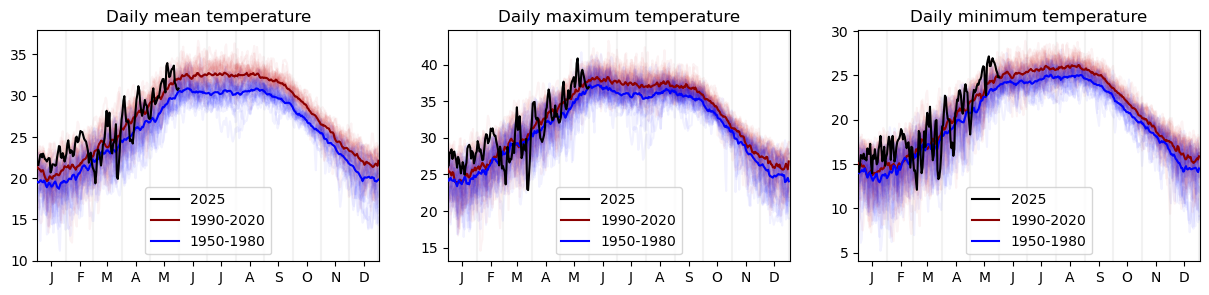

In [37]:
varbls = ["tmean", "tx", "tn"]

nc = len(varbls); nr = 1

fig, axs = plt.subplots(ncols = nc, nrows = nr, figsize = (nc*5, nr*3), dpi = 100)
plt.subplots_adjust(hspace = 0.35)
if nc*nr == 1: axs = [axs]

days = pd.date_range(start = "2026-01-01", end = "2027-01-01")
labelticks = [i+1 for i in range(len(days)) if (days[i].day) == 15]
labels = [days[i].strftime("%b")[0] for i in range(len(days)) if (days[i].day) == 15]

for i in range(len(varbls)):
    ax = axs[i]
    varnm = varbls[i]
    ttl = ["mean", "maximum", "minimum"][i]

    ts = eval(varnm)
    ts = ts.sel(time = slice(None, "2026-05"))
    y = 2026; ts_y = ts.sel(time = ts.time.dt.year == y); ax.plot(ts_y.time.dt.dayofyear, ts_y, color = "k", label = "2026", zorder = 999)

    p1 = ["1990","2020"]
    p2 = ["1950","1980"]
    ax.plot(ts.sel(time = slice(*p1)).groupby("time.dayofyear").mean(), color = "darkred", zorder = 99)
    ax.plot(ts.sel(time = slice(*p2)).groupby("time.dayofyear").mean(), color = "blue", zorder = 99)

    for y in range(int(p1[0]),int(p1[1])):
        ts_y = ts.sel(time = ts.time.dt.year == y)
        ax.plot(ts_y.time.dt.dayofyear, ts_y, color = "tab:red", alpha = 0.05, label = "_years")

    for y in range(int(p2[0]),int(p2[1])):
        ts_y = ts.sel(time = ts.time.dt.year == y)
        ax.plot(ts_y.time.dt.dayofyear, ts_y, color = "blue", alpha = 0.05, label = "_years")

    # for y in range(1960,1990):
    #     ts_y = ts.sel(time = ts.time.dt.year == y)
    #     ax.plot(ts_y.time.dt.dayofyear, ts_y, color = "tab:blue", alpha = 0.5, label = "_years")

    
    ax.set_title("Daily "+ttl+" temperature")
    
    ax.legend(["2025", "-".join(p1), "-".join(p2)])
    ax.set_xticks(labelticks)
    ax.set_xticklabels(labels)
    [ax.axvline(x, color = "k", alpha = 0.05) for x in range(len(days)) if (days[x].day) == 1]

    ax.margins(x = 0)

plt.savefig("fig/season-cycle.png")

# Fit gridded trend

## Fit trend over larger region (monthly means only)

### Fresh download of monthly mean May data only

In [48]:
! wget https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-2/2026-05-27/543bf445edb63ccebf681325432b6365.nc -O data/tas-monthly-may_era5_peninsula.nc

--2026-05-27 22:12:04--  https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-2/2026-05-27/543bf445edb63ccebf681325432b6365.nc
Resolving object-store.os-api.cci2.ecmwf.int (object-store.os-api.cci2.ecmwf.int)... 2a0c:5bc0:4c:ff::889c:8803, 136.156.136.3
Connecting to object-store.os-api.cci2.ecmwf.int (object-store.os-api.cci2.ecmwf.int)|2a0c:5bc0:4c:ff::889c:8803|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874152 (854K) [application/netcdf]
Saving to: ‘data/tas-monthly-may_era5_peninsula.nc’

data/tas-monthly-ma 100%[===================>] 853.66K  5.11MB/s    in 0.2s    

2026-05-27 22:12:04 (5.11 MB/s) - ‘data/tas-monthly-may_era5_peninsula.nc’ saved [874152/874152]



In [49]:
! wget https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-3/2026-05-27/dad13d760e93d91eb5fc8a4d8302b233.nc -O data/tas-monthly-may_era5land_peninsula.nc

--2026-05-27 22:12:04--  https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-3/2026-05-27/dad13d760e93d91eb5fc8a4d8302b233.nc
Resolving object-store.os-api.cci2.ecmwf.int (object-store.os-api.cci2.ecmwf.int)... 2a0c:5bc0:4c:ff::889c:8803, 136.156.136.3
Connecting to object-store.os-api.cci2.ecmwf.int (object-store.os-api.cci2.ecmwf.int)|2a0c:5bc0:4c:ff::889c:8803|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3857337 (3.7M) [application/netcdf]
Saving to: ‘data/tas-monthly-may_era5land_peninsula.nc’

data/tas-monthly-ma 100%[===================>]   3.68M  15.2MB/s    in 0.2s    

2026-05-27 22:12:05 (15.2 MB/s) - ‘data/tas-monthly-may_era5land_peninsula.nc’ saved [3857337/3857337]



### Load & fit trend

In [ ]:
ds_nm = "era5"
da = xr.open_dataset("data/tas-monthly-may_"+ds_nm+"_peninsula.nc").t2m.reset_coords(drop = True)

if ds_nm == "era5":
    rm = regionmask.defined_regions.natural_earth_v5_1_2.land_50.mask(da)
    da = da.where(rm == 0)

gmst = pd.read_table("data/gmst.txt", sep = " +", comment = "#", engine = "python", header = None, names = ["year", "gmst"], index_col = "year").loc[da.valid_time.dt.year]
coeffs = da.assign_coords(valid_time = gmst.gmst.values).polyfit("valid_time", deg = 1).polyfit_coefficients

In [ ]:
fig, ax = plt.subplots(subplot_kw = {"projection" : cartopy.crs.PlateCarree(), "extent" : [38,45,17,25]}, figsize = (nc*4,6), dpi = 100)

# plot_kw = {"vmin" : -3, "vmax" : 3, "cmap" : "RdBu_r", "add_colorbar" : False}
v = 3
coeffs.sel(degree = 1).plot(ax = ax, cmap = "RdBu_r", vmin = -v, vmax = v)

ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
ax.scatter(39.8,21.4, color = "k", marker = "x")

ax.plot([x0-k,x0-k,x0+k,x0+k,x0-k], [y0-k,y0+k,y0+k,y0-k,y0-k], color = "k", lw = 2, alpha = 0.5)

## Trend over smaller region

In [94]:
varnm = "tmean"

if varnm == "tmean":
    da = xr.open_dataset("data/t2m_era5_compiled.nc").t2m
    da = da.groupby("time.month")[5].resample(time = "MS").mean().dropna("time")
elif varnm == "tx1x":
    da = xr.open_dataset("data/tmax_era5_compiled.nc").tmax
    da = da.groupby("time.month")[5].resample(time = "MS").max().dropna("time")

In [95]:
rm = regionmask.defined_regions.natural_earth_v5_1_2.land_50.mask(da)
da = da.where(rm == 0)

In [96]:
gmst = pd.read_table("data/gmst.txt", sep = " +", comment = "#", engine = "python", header = None, names = ["year", "gmst"], index_col = "year").loc[slice("1950","2026")]

coeffs = da.assign_coords(time = gmst.gmst.values).polyfit("time", deg = 1).polyfit_coefficients

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


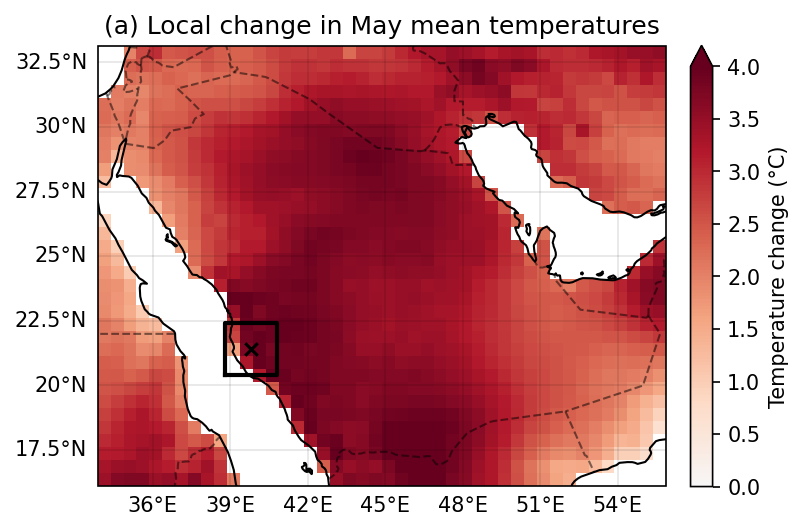

In [97]:
nc = 1
fig, ax = plt.subplots(ncols = nc, subplot_kw = {"projection" : cartopy.crs.PlateCarree()}, figsize = (nc*6,4), dpi = 150)

# plot_kw = {"vmin" : -3, "vmax" : 3, "cmap" : "RdBu_r", "add_colorbar" : False}
v = 4
(coeffs.sel(degree = 1) * 1.3).plot(ax = ax, cmap = "RdBu_r", norm = MidpointNormalise(midpoint = 0, vmin = 0, vmax = 4), 
                                    cbar_kwargs = {"location" : "right", "label" : "Temperature change (°C)", "pad" : 0.035, "shrink" : 0.955})

ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
ax.scatter(39.8,21.4, color = "k", marker = "x")
ax.gridlines(color = "k", alpha = 0.1, draw_labels = ["bottom", "left"])

ax.set_title("(a) Local change in May mean temperatures")

ax.plot([x0-k,x0-k,x0+k,x0+k,x0-k], [y0-k,y0+k,y0+k,y0-k,y0-k], color = "k", lw = 2, alpha = 1)

plt.savefig("fig/warming-map.png")

# Trends per calendar month

## Trends in monthly mean temperatures

In [98]:
gmst = pd.read_table("data/gmst.txt", comment = "#", sep = " +", engine = "python", header = None, names = ["year", "gmst"], index_col = "year")

t2m = xr.open_dataset("data/t2m-daily_box_era5.nc").t2m
t2m_monthly = t2m.resample(time = "MS").mean()
t2m_monthly = t2m_monthly.sel(time = slice(None, "2026-05"))

In [99]:
df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), 
            [t2m_monthly.groupby("time.month")[m].rename(str(m)).to_dataframe() for m in [5,6,7,8]])

In [100]:
df = []
for m in [5,6,7,8]:
    df_m = t2m_monthly.groupby("time.month")[m].rename(str(m))
    df_m = df_m.assign_coords(time = df_m.time.dt.year).to_dataframe()
    df.append(df_m)

df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), df)

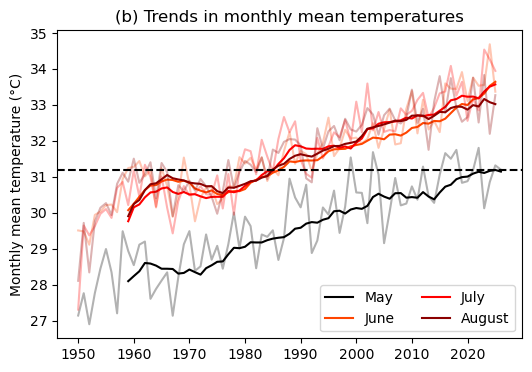

In [101]:
fig, ax = plt.subplots(figsize = (6,4), dpi = 100)

cols = ["k", "orangered", "red", "darkred"]
months = [5,6,7,8]

for i in range(4):
    m = months[i]
    ax.plot(df.index, df[[str(m)]], alpha = 0.3, color = cols[i], label = "_")
    ax.plot(df.index, df[[str(m)]].rolling(10).mean(), alpha = 1, color = cols[i], label = datetime.datetime(2026,m,1).strftime("%B"))
#     df[[str(m)]].rolling(10).mean().plot(ax = ax, alpha = 1, color = cols[i])

ax.axhline(df.loc[slice(2016,None), "5"].mean(), ls = "--", color = "k")

ax.legend(loc = "lower right", ncols = 2)
ax.set_xlabel("")
ax.set_ylabel("Monthly mean temperature (°C)")
ax.set_title("(b) Trends in monthly mean temperatures")

plt.savefig("fig/trends-per-month_box_era5_tmean.png")

## Trends in monthly peak temperatures

In [26]:
gmst = pd.read_table("data/gmst.txt", comment = "#", sep = " +", engine = "python", header = None, names = ["year", "gmst"], index_col = "year")

t2m = xr.open_dataset("data/tmax-daily_box_era5.nc").tmax
t2m_monthly = t2m.resample(time = "MS").max()
t2m_monthly = t2m_monthly.sel(time = slice(None, "2026-05"))

In [27]:
df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), 
            [t2m_monthly.groupby("time.month")[m].rename(str(m)).to_dataframe() for m in [5,6,7,8]])

In [28]:
df = []
for m in [5,6,7,8]:
    df_m = t2m_monthly.groupby("time.month")[m].rename(str(m))
    df_m = df_m.assign_coords(time = df_m.time.dt.year).to_dataframe()
    df.append(df_m)

df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), df)

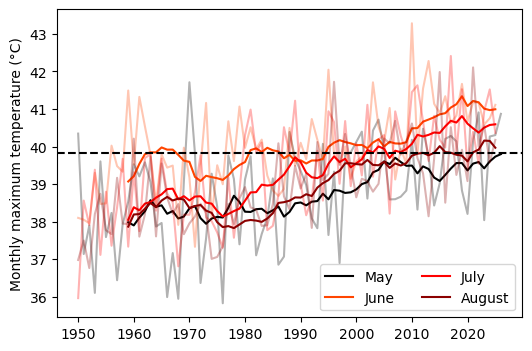

In [29]:
fig, ax = plt.subplots(figsize = (6,4), dpi = 100)

cols = ["k", "orangered", "red", "darkred"]
months = [5,6,7,8]

for i in range(4):
    m = months[i]
    ax.plot(df.index, df[[str(m)]], alpha = 0.3, color = cols[i], label = "_")
    ax.plot(df.index, df[[str(m)]].rolling(10).mean(), alpha = 1, color = cols[i], label = datetime.datetime(2026,m,1).strftime("%B"))
#     df[[str(m)]].rolling(10).mean().plot(ax = ax, alpha = 1, color = cols[i])

ax.axhline(df.loc[slice(2016,None), "5"].mean(), ls = "--", color = "k")

ax.legend(loc = "lower right", ncols = 2)
ax.set_xlabel("")
ax.set_ylabel("Monthly maximum temperature (°C)")

plt.savefig("fig/trends-per-month_box_era5_tx1x.png")